In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display # pyright: ignore[reportUnknownVariableType]

In [2]:
from utils import (
    format_menu,
    input_parser,
    available_assignments,
    day_menu_cost,
    InputData,
    Schedule,
    Assignment,
)

In [3]:
sample_input = """% Comments
% Cost <food-item> <value>
C TC 1
C DF 1
C PM 1
C GJ 1
% Group size
G 2
% Inputs - books / notes. It ends with -1
I 1 2 3 4 5 6 -1
% Outputs - final outcome. It ends with -1
O 13 14 17 -1
% Assignment dependency list
% A <id> <input1> <input2> <outcome> <Food-name>
A 1 1 3 7 TC
A 2 4 2 8 TC
A 3 1 3 9 TC
A 4 2 3 10 PM
A 5 7 8 11 TC
A 6 4 6 12 TC
A 7 6 9 13 PM
A 8 10 5 14 GJ
A 9 1 11 15 DF
A 10 3 12 16 TC
A 11 15 16 17 DF"""

input_data = input_parser(sample_input)
input_data

{'food_cost': {'TC': 1, 'DF': 1, 'PM': 1, 'GJ': 1},
 'group_size': 2,
 'initial_inputs': {1, 2, 3, 4, 5, 6},
 'outputs': {13, 14, 17},
 'assignments': {1: {'id': 1, 'prereqs': (1, 3), 'outcome': 7, 'food': 'TC'},
  2: {'id': 2, 'prereqs': (4, 2), 'outcome': 8, 'food': 'TC'},
  3: {'id': 3, 'prereqs': (1, 3), 'outcome': 9, 'food': 'TC'},
  4: {'id': 4, 'prereqs': (2, 3), 'outcome': 10, 'food': 'PM'},
  5: {'id': 5, 'prereqs': (7, 8), 'outcome': 11, 'food': 'TC'},
  6: {'id': 6, 'prereqs': (4, 6), 'outcome': 12, 'food': 'TC'},
  7: {'id': 7, 'prereqs': (6, 9), 'outcome': 13, 'food': 'PM'},
  8: {'id': 8, 'prereqs': (10, 5), 'outcome': 14, 'food': 'GJ'},
  9: {'id': 9, 'prereqs': (1, 11), 'outcome': 15, 'food': 'DF'},
  10: {'id': 10, 'prereqs': (3, 12), 'outcome': 16, 'food': 'TC'},
  11: {'id': 11, 'prereqs': (15, 16), 'outcome': 17, 'food': 'DF'}}}

In [4]:
def build_graph(data: InputData) -> tuple[dict[int, int], dict[int, list[int]]]:
    assignments = data["assignments"]

    outcome_to_assignment: dict[int, int] = {}
    for aid, info in assignments.items():
        outcome_to_assignment[info["outcome"]] = aid

    children: dict[int, list[int]] = {}
    for aid, info in assignments.items():
        for p in info["prereqs"]:
            if p in outcome_to_assignment:
                parent = outcome_to_assignment[p]
                if parent not in children:
                    children[parent] = list()
                children[parent].append(aid)

    return outcome_to_assignment, children


outcome_to_assignment, children = build_graph(input_data)
children

{1: [5], 2: [5], 3: [7], 4: [8], 5: [9], 6: [10], 9: [11], 10: [11]}

In [5]:
def compute_depths(
    assignments: dict[int, Assignment], children: dict[int, list[int]]
) -> dict[int, int]:
    cache: dict[int, int] = {}

    def depth(aid: int) -> int:
        if aid in cache:
            return cache[aid]
        if aid not in children or len(children[aid]) == 0:
            result = 1
        else:
            result = 1 + max(depth(ch) for ch in children[aid])
        cache[aid] = result
        return result

    return {aid: depth(aid) for aid in assignments}


depths = compute_depths(input_data["assignments"], children)
depths

{1: 4, 2: 4, 3: 2, 4: 2, 5: 3, 6: 3, 7: 1, 8: 1, 9: 2, 10: 2, 11: 1}

In [6]:
def choose_by_food_cost(avail: list[int], data: InputData) -> list[int]:
    return sorted(
        avail,
        key=lambda aid: (data["food_cost"][data["assignments"][aid]["food"]], aid),
    )


def choose_by_dependency_depth(
    avail: list[int],
    data: InputData,
    depths: dict[int, int],
    children: dict[int, list[int]],
) -> list[int]:
    return sorted(
        avail,
        key=lambda aid: (
            -depths[aid],
            -len(children.get(aid, [])),
            data["food_cost"][data["assignments"][aid]["food"]],
            aid,
        ),
    )

In [7]:
def greedy_schedule(
    data: InputData, strategy: str = "food_cost"
) -> tuple[list[Schedule], int, int]:
    assignments = data["assignments"]
    g = data["group_size"]

    _outcome_to_assignment, children = build_graph(data)
    depths = compute_depths(assignments, children)

    completed: set[int] = set()
    available_resources: set[int] = set(data["initial_inputs"])

    schedule: list[Schedule] = []
    total_cost = 0
    day = 1

    while len(completed) < len(assignments):
        avail = available_assignments(data, completed, available_resources)

        if not avail:
            raise ValueError(
                "No available assignment found. Input may contain a cycle or invalid dependency."
            )

        if strategy == "food_cost":
            ordered = choose_by_food_cost(avail, data)
        elif strategy == "dependency_depth":
            ordered = choose_by_dependency_depth(avail, data, depths, children)
        else:
            raise ValueError("Unknown strategy")

        chosen = ordered[:g]

        for aid in chosen:
            completed.add(aid)
            available_resources.add(assignments[aid]["outcome"])

        menu_counter, cost_today = day_menu_cost(chosen, data)
        total_cost += cost_today

        schedule.append(
            Schedule(
                day=day,
                assignments=chosen,
                menu=menu_counter,
                cost=cost_today,
            )
        )

        day += 1

    return schedule, len(schedule), total_cost

In [8]:
def print_schedule_result(strategy_name: str, result: tuple[list[Schedule], int, int]):
    schedule, total_days, total_cost = result
    print(f"Strategy: {strategy_name}")
    for entry in schedule:
        day = entry["day"]
        tasks = ", ".join(f"A{x}" for x in entry["assignments"])
        menu = format_menu(entry["menu"])
        print(f"Day-{day}: {tasks}    Menu: {menu}    Cost: {entry['cost']}")
    print(f"Total Days: {total_days}    Total Cost: {total_cost}")
    print("-" * 70)


res_food = greedy_schedule(input_data, strategy="food_cost")
res_depth = greedy_schedule(input_data, strategy="dependency_depth")

print_schedule_result("Greedy by Food Cost", res_food)
print_schedule_result("Greedy by Dependency Depth", res_depth)

Strategy: Greedy by Food Cost
Day-1: A1, A2    Menu: 2-TC    Cost: 2
Day-2: A3, A4    Menu: 1-PM, 1-TC    Cost: 2
Day-3: A5, A6    Menu: 2-TC    Cost: 2
Day-4: A7, A8    Menu: 1-GJ, 1-PM    Cost: 2
Day-5: A9, A10    Menu: 1-DF, 1-TC    Cost: 2
Day-6: A11    Menu: 1-DF    Cost: 1
Total Days: 6    Total Cost: 11
----------------------------------------------------------------------
Strategy: Greedy by Dependency Depth
Day-1: A1, A2    Menu: 2-TC    Cost: 2
Day-2: A5, A6    Menu: 2-TC    Cost: 2
Day-3: A3, A4    Menu: 1-PM, 1-TC    Cost: 2
Day-4: A9, A10    Menu: 1-DF, 1-TC    Cost: 2
Day-5: A7, A8    Menu: 1-GJ, 1-PM    Cost: 2
Day-6: A11    Menu: 1-DF    Cost: 1
Total Days: 6    Total Cost: 11
----------------------------------------------------------------------


In [9]:
def schedule_to_dataframe(
    data: InputData, result: tuple[list[Schedule], int, int], strategy_name: str
) -> tuple[pd.DataFrame, int, int]:
    schedule, total_days, total_cost = result
    rows: list[dict[str, str | int]] = []

    for entry in schedule:
        day = entry["day"]
        assignments = [f"A{x}" for x in entry["assignments"]]
        menu_dict = dict(entry["menu"])

        row: dict[str, str | int] = {
            "Strategy": strategy_name,
            "Day": day,
            "Assignments": ", ".join(assignments),
            "Num_Assignments": len(entry["assignments"]),
            "Menu": (
                ", ".join([f"{v}-{k}" for k, v in sorted(menu_dict.items())])
                if menu_dict
                else "None"
            ),
            "Daily_Cost": entry["cost"],
        }

        for food in data["food_cost"].keys():
            row[f"Food_{food}"] = menu_dict.get(food, 0)

        rows.append(row)

    df = pd.DataFrame(rows)
    return df, total_days, total_cost


df_food, total_days_food, total_cost_food = schedule_to_dataframe(
    input_data, res_food, "Greedy by Food Cost"
)
df_depth, total_days_depth, total_cost_depth = schedule_to_dataframe(
    input_data, res_depth, "Greedy by Dependency Depth"
)

display(df_food)
display(df_depth)

,Strategy,Day,Assignments,Num_Assignments,Menu,Daily_Cost,Food_TC,Food_DF,Food_PM,Food_GJ
0,Greedy by Food Cost,1,"A1, A2",2,2-TC,2,2,0,0,0
1,Greedy by Food Cost,2,"A3, A4",2,"1-PM, 1-TC",2,1,0,1,0
2,Greedy by Food Cost,3,"A5, A6",2,2-TC,2,2,0,0,0
3,Greedy by Food Cost,4,"A7, A8",2,"1-GJ, 1-PM",2,0,0,1,1
4,Greedy by Food Cost,5,"A9, A10",2,"1-DF, 1-TC",2,1,1,0,0
5,Greedy by Food Cost,6,A11,1,1-DF,1,0,1,0,0


,Strategy,Day,Assignments,Num_Assignments,Menu,Daily_Cost,Food_TC,Food_DF,Food_PM,Food_GJ
0,Greedy by Dependency Depth,1,"A1, A2",2,2-TC,2,2,0,0,0
1,Greedy by Dependency Depth,2,"A5, A6",2,2-TC,2,2,0,0,0
2,Greedy by Dependency Depth,3,"A3, A4",2,"1-PM, 1-TC",2,1,0,1,0
3,Greedy by Dependency Depth,4,"A9, A10",2,"1-DF, 1-TC",2,1,1,0,0
4,Greedy by Dependency Depth,5,"A7, A8",2,"1-GJ, 1-PM",2,0,0,1,1
5,Greedy by Dependency Depth,6,A11,1,1-DF,1,0,1,0,0


,Strategy,Total Days,Total Cost
0,Greedy by Food Cost,6,11
1,Greedy by Dependency Depth,6,11


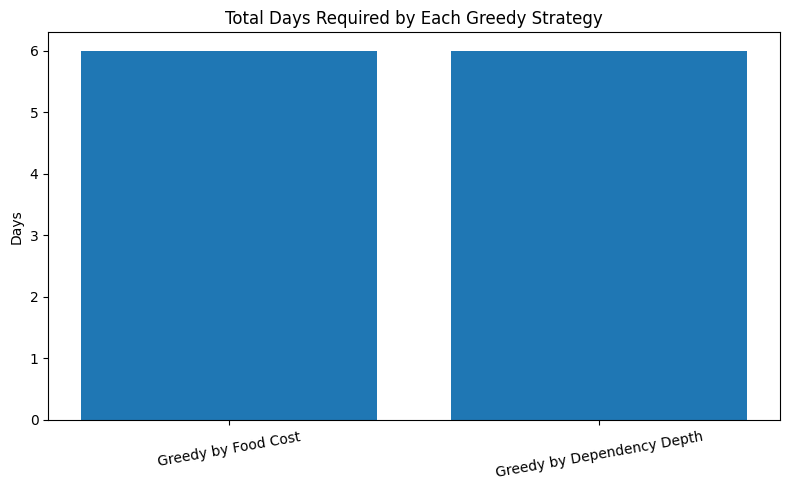

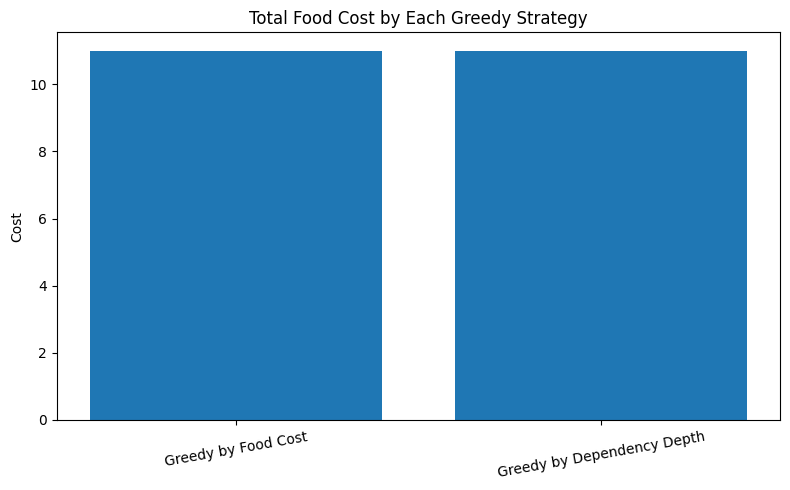

In [10]:
summary_df = pd.DataFrame({
    "Strategy": ["Greedy by Food Cost", "Greedy by Dependency Depth"],
    "Total Days": [total_days_food, total_days_depth],
    "Total Cost": [total_cost_food, total_cost_depth]
})

display(summary_df)

plt.figure(figsize=(8, 5))
plt.bar(summary_df["Strategy"], summary_df["Total Days"])
plt.title("Total Days Required by Each Greedy Strategy")
plt.ylabel("Days")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["Strategy"], summary_df["Total Cost"])
plt.title("Total Food Cost by Each Greedy Strategy")
plt.ylabel("Cost")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

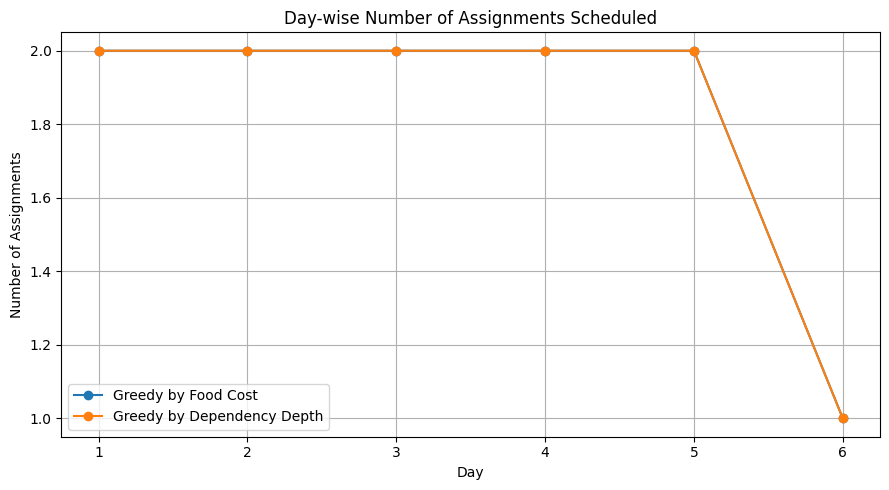

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(df_food["Day"], df_food["Num_Assignments"], marker='o', label="Greedy by Food Cost")
plt.plot(df_depth["Day"], df_depth["Num_Assignments"], marker='o', label="Greedy by Dependency Depth")
plt.title("Day-wise Number of Assignments Scheduled")
plt.xlabel("Day")
plt.ylabel("Number of Assignments")
plt.xticks(df_food["Day"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

,Greedy by Food Cost,Greedy by Dependency Depth
TC,6,6
DF,2,2
PM,2,2
GJ,1,1


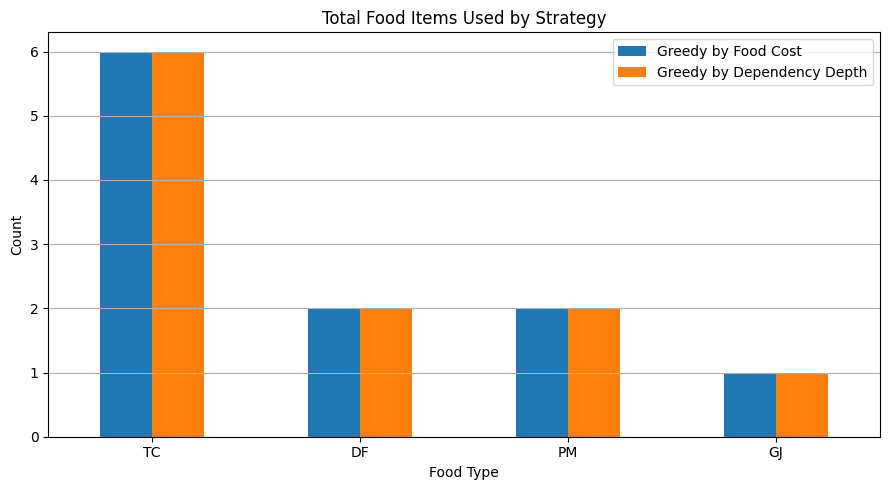

In [12]:
food_cols = [col for col in df_food.columns if col.startswith("Food_")]

food_totals_food = df_food[food_cols].sum()
food_totals_depth = df_depth[food_cols].sum()

food_compare = pd.DataFrame({
    "Greedy by Food Cost": food_totals_food.values,
    "Greedy by Dependency Depth": food_totals_depth.values
}, index=[col.replace("Food_", "") for col in food_cols])

display(food_compare)

food_compare.plot(kind="bar", figsize=(9, 5))
plt.title("Total Food Items Used by Strategy")
plt.xlabel("Food Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

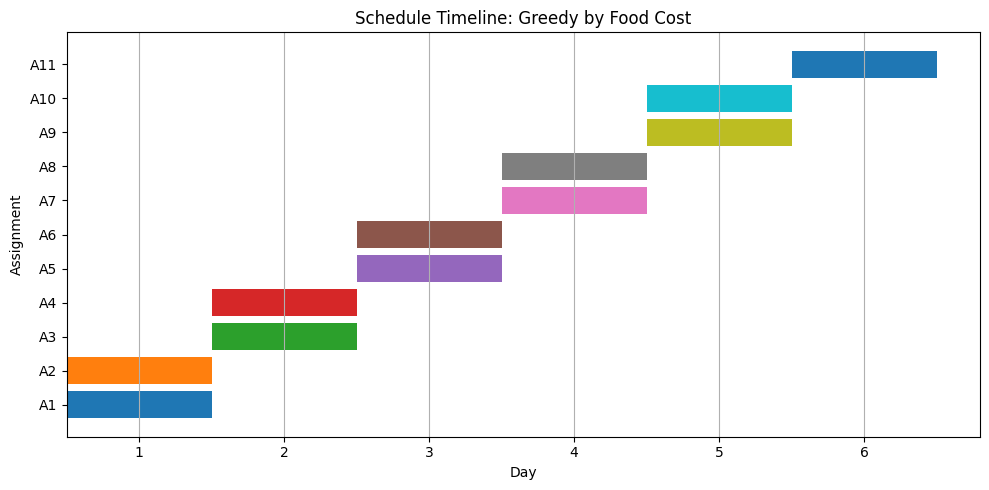

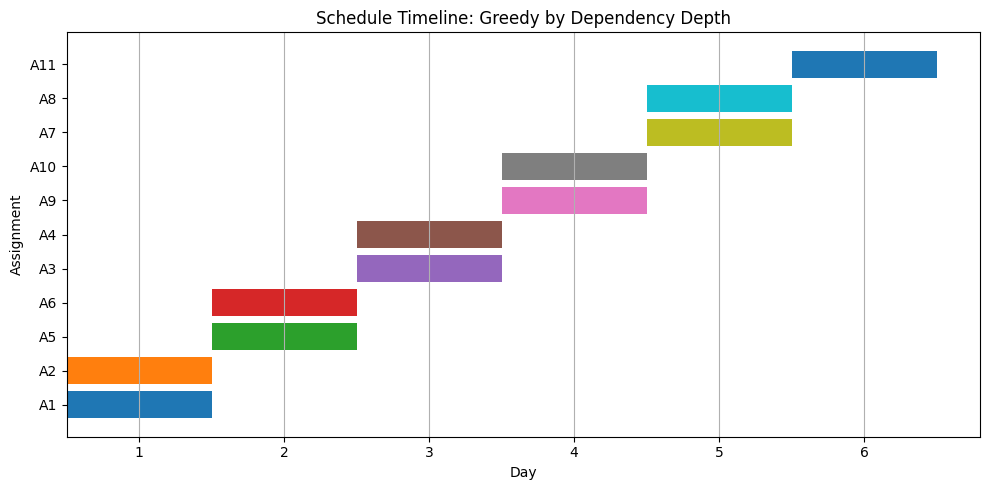

In [13]:
def plot_schedule_timeline(df: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 5))
    for _, row in df.iterrows():
        tasks = row["Assignments"].split(", ")
        for task in tasks:
            task_num = int(task[1:])
            plt.barh(task, 1, left=row["Day"]-0.5)

    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel("Assignment")
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

plot_schedule_timeline(df_food, "Schedule Timeline: Greedy by Food Cost")
plot_schedule_timeline(df_depth, "Schedule Timeline: Greedy by Dependency Depth")

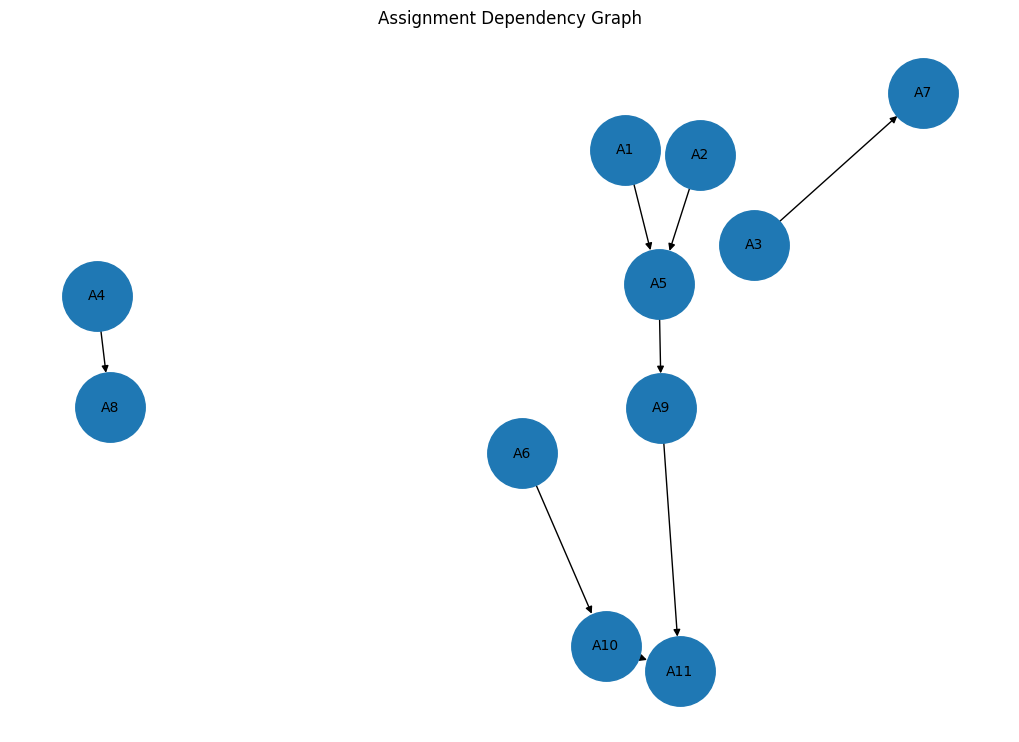

In [14]:
def build_assignment_dependency_graph(data: InputData):
    G = nx.DiGraph()
    assignments = data["assignments"]

    outcome_to_assignment = {}
    for aid, info in assignments.items():
        outcome_to_assignment[info["outcome"]] = aid

    for aid in assignments:
        G.add_node(f"A{aid}")

    for aid, info in assignments.items():
        for prereq in info["prereqs"]:
            if prereq in outcome_to_assignment:
                parent = outcome_to_assignment[prereq]
                G.add_edge(f"A{parent}", f"A{aid}")

    return G

G_dep = build_assignment_dependency_graph(input_data)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_dep, seed=42)
nx.draw(
    G_dep, pos,
    with_labels=True,
    node_size=2500,
    font_size=10,
    arrows=True
)
plt.title("Assignment Dependency Graph")
plt.show()